# Getting started — your first seminar notebook

This notebook teaches you everything you need in order to run the other notebooks of this seminar: what a notebook is, how to run one in Google Colab, and how to keep your API key safe.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/advanced-genai-actuarial/blob/main/notebooks/00_getting_started/00_getting_started.ipynb)

EAA seminar **E0572 — Advanced Applications of Generative AI in Actuarial Science**, Vilnius, 1–2 October 2026. Lecturer: Dr Simon Hatzesberger.

Repository: [simonhatzesberger/advanced-genai-actuarial](https://github.com/simonhatzesberger/advanced-genai-actuarial)

No prior experience with Python or Jupyter is assumed — if you have never opened a notebook before, this one is written for you.

## Learning objectives

After working through this notebook you will be able to:

- **run** a notebook cell and recognise the three kinds of output it can produce;
- **explain** why the order in which you run cells matters more than their order on the page;
- **open** any seminar notebook in Google Colab and keep your own copy of it;
- **store** your API key as a Colab secret and read it in code without ever exposing it;
- **distinguish** reading a notebook from running it, and say which of the two spends money.

## Contents

1. [What a Jupyter notebook is, and cell anatomy](#1-what-a-jupyter-notebook-is-and-cell-anatomy)
2. [Running cells: order and state](#2-running-cells-order-and-state)
3. [What outputs look like](#3-what-outputs-look-like)
4. [Installing packages, magics and shell commands](#4-installing-packages-magics-and-shell-commands)
5. [Running it in Google Colab](#5-running-it-in-google-colab)
6. [Your API key, step by step (Colab Secrets)](#6-your-api-key-step-by-step-colab-secrets)
7. [Reading a notebook versus running it](#7-reading-a-notebook-versus-running-it)
8. [Running locally instead](#8-running-locally-instead)
9. [Check your setup](#9-check-your-setup)
10. [Optional: one real API call](#10-optional-one-real-api-call)

---

## 1 What a Jupyter notebook is, and cell anatomy

A Jupyter notebook is a document that interleaves three things: the explanation you are reading now, Python that you can run, and the results that running it produces. It is one file, with the extension `.ipynb`, and it opens in a browser. Everything in this seminar — slides aside — is a notebook.

The document is built from **cells**, stacked from top to bottom. A cell is either text or code, and a code cell may carry its results underneath it.

| Part | What it holds | How to recognise it |
| --- | --- | --- |
| **Markdown cell** | Formatted text: headings, bullet points, tables, formulae. No Python, nothing to execute. | No counter on the left. Double-click it to see its raw text, run it to render it again. |
| **Code cell** | Python. This is the part that does something. | A run button (▶) on the left, and next to it the execution counter `In [ ]`. |
| **Output** | Whatever the code cell produced the last time it ran: printed text, a table, a chart, an error message. | It sits directly under its code cell and is saved in the file, so you can read a notebook without running it. |

The seminar notebooks arrive with their outputs already saved, so you can read one straight through without running anything. Run a cell yourself and its saved output is replaced by whatever your own machine produces.

---

## 2 Running cells: order and state

Click into a code cell and press **Shift + Enter**. The cell runs, and the cursor moves on to the next cell. While it is busy you see `In [*]` on its left; when it finishes, the star turns into a number, for example `In [5]`. That number counts how many cells have run in this session — it is **not** the position of the cell on the page.

Here is the one idea worth carrying away from this whole notebook: all cells share a **single Python session**, so a cell sees whatever the cells you ran before it left behind. The order you run cells in matters; the order they appear on screen does not. The two cells below show what that means.

In [1]:
# Run this cell first.
claims_so_far = 120
print("claims_so_far =", claims_so_far)

claims_so_far = 120


In [2]:
# Now run this one. It does not set the value, it changes whatever the session holds.
claims_so_far = claims_so_far + 30
print("claims_so_far =", claims_so_far)

claims_so_far = 150


Run the second cell once and it prints 150. Run it again and it prints 180, then 210, and so on. Nothing on the page has changed — only the session has. This is how notebooks confuse people: a number that no longer matches the code above it, or a variable that exists only because of a cell you have since deleted.

The reliable way out is to throw the session away and start again: **Runtime → Restart session and run all** in Colab (**Kernel → Restart Kernel and Run All Cells** in JupyterLab). Do this whenever a notebook stops making sense, and always before you trust a result.

---

## 3 What outputs look like

A code cell can show you three kinds of result, and the seminar uses all three: a printed line, a table, and a chart. The three cells below produce one each, using a tiny motor portfolio.

The figures are **illustrative** — five age bands invented for this notebook. They are not the data of any insurer. The last column is the claim frequency, claims divided by exposure years; multiply it back by the exposure and you recover the claim count, 0.138 × 420 ≈ 58.

In [3]:
# A printed line — the simplest output there is.
print("Motor portfolio extract: 5 age bands, 402 claims. Illustrative figures only.")

Motor portfolio extract: 5 age bands, 402 claims. Illustrative figures only.


In [4]:
import pandas as pd

# Illustrative motor figures, invented for this notebook. Not real portfolio data.
motor = pd.DataFrame(
    {
        "age_band": ["18–25", "26–40", "41–60", "61–75", "76+"],
        "exposure_years": [420.0, 1850.0, 2310.0, 960.0, 180.0],
        "claims": [58, 141, 139, 52, 12],
    }
)
motor["frequency"] = (motor["claims"] / motor["exposure_years"]).round(3)

# A DataFrame as the last line of a cell is shown as a table.
motor

,age_band,exposure_years,claims,frequency
0,18–25,420.0,58,0.138
1,26–40,1850.0,141,0.076
2,41–60,2310.0,139,0.060
3,61–75,960.0,52,0.054
4,76+,180.0,12,0.067


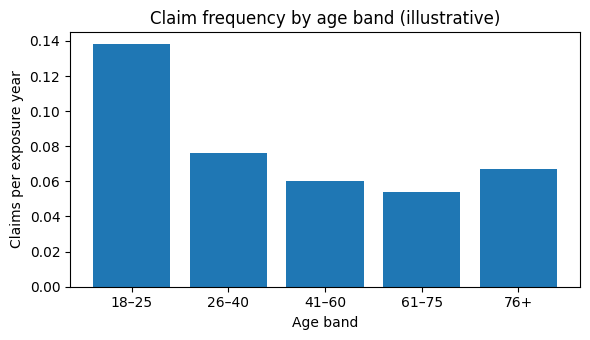

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.0, 3.5))
ax.bar(motor["age_band"], motor["frequency"])
ax.set_title("Claim frequency by age band (illustrative)")
ax.set_xlabel("Age band")
ax.set_ylabel("Claims per exposure year")
fig.tight_layout()
plt.show()

---

## 4 Installing packages, magics and shell commands

Notebooks understand a few instructions that are not Python:

- `%pip install somepackage` installs a package into the session that is running this notebook. Prefer this `%` form over a bare `pip`: it installs into the right environment.
- `!` runs the rest of the line as a shell command, for example `!python --version`.
- `%%time`, written on the first line of a cell, reports how long the whole cell took.

**You will normally never install anything by hand.** The seminar notebooks pin their dependencies and list them in the repository’s single `requirements.txt`, and Colab already provides almost all of them. The install line below is therefore commented out, so that running this notebook from top to bottom changes nothing on your machine.

In [6]:
# Both lines are commented out on purpose: running this notebook installs nothing
# and touches nothing. Remove the leading "#" only when you are asked to.

# %pip install --quiet openai
# !python --version

In [7]:
%%time
# %%time has to stand on the first line of the cell to work.
squares = [n * n for n in range(1_000_000)]
print(f"{len(squares):,} numbers squared")

1,000,000 numbers squared
CPU times: total: 62.5 ms
Wall time: 51.7 ms


---

## 5 Running it in Google Colab

Google Colab is Jupyter hosted by Google. The seminar uses it because nothing has to be installed and everyone in the room then works on one identical Python setup.

- **The badge.** The Open-in-Colab badge at the top of this notebook is simply a link that asks Colab to fetch this file from GitHub and open it. All you need is a Google account.
- **Where the code runs.** On a Google machine, not on yours. Your laptop only displays the page, and any file the notebook creates lives on that remote machine.
- **Sessions time out.** After a spell of inactivity Colab disconnects and discards the session. What you lose is the *state* — every variable, every import, everything you installed. What you keep is the notebook itself: all the text, all the code, and any outputs already saved in it.
- **Reconnecting.** Click **Connect** at the top right, or simply run a cell, and Colab hands you a fresh session. Because that session is empty, run the notebook again from the top: **Runtime → Run all**.
- **Keeping your edits.** Changes you make to a notebook opened from GitHub do not go back to the repository, and they are not kept for you. Choose **File → Save a copy in Drive** and carry on working in that copy, which is yours.

---

## 6 Your API key, step by step (Colab Secrets)

An API key is a password that lets your code talk to a model provider. Colab keeps keys in **Secrets**, stored with your Google account rather than inside the notebook, so the key is never part of the file you share.

1. In Colab, click the **key icon** in the left sidebar. The **Secrets** panel opens.
2. Click **Add new secret** and give it exactly the name `OPENAI_API_KEY` — capitals and underscores, no spaces.
3. Paste the key into the value field.
4. Switch **Notebook access** on for this notebook. Without that switch the notebook cannot see the secret.
5. Read it in code with two lines:

```python
from google.colab import userdata
api_key = userdata.get("OPENAI_API_KEY")
```

> **Warning.** Never paste a key into a code cell, never leave one standing in a cell’s output, never commit one to a repository, and never let one appear in a screenshot. Anyone who sees a key can spend on it. If a key is ever exposed, treat it as compromised and have it revoked.

The seminar key handed out in the room is temporary, spend-capped and revoked when the seminar ends. It is for the seminar examples only: **no company, client or personal data** goes to a model in this seminar.

The cell below reports only *whether* a key is visible, and how many characters long it is. It never prints the value, it works unchanged outside Colab by falling back to the environment variable `OPENAI_API_KEY` (section 8 shows how to set it on your own machine), and it does not fail when there is no key — which is the normal case.

In [8]:
import os


def find_api_key(name: str = "OPENAI_API_KEY") -> str | None:
    """Return the key if this environment can see one, otherwise None. Never raises."""
    try:
        from google.colab import userdata  # available on Colab only

        value = userdata.get(name)
        if value:
            return value
    except Exception:
        # Not on Colab, or the secret does not exist, or notebook access is off.
        pass
    return os.environ.get(name) or None


key = find_api_key()
if key:
    print(f"[PASS] A secret named OPENAI_API_KEY is visible ({len(key)} characters long).")
    print("       Its value is never printed - not here, not anywhere.")
else:
    print("[ATTENTION] No secret named OPENAI_API_KEY is visible to this notebook.")
    print("            That is fine for reading: every notebook ships with its outputs saved.")

[ATTENTION] No secret named OPENAI_API_KEY is visible to this notebook.
            That is fine for reading: every notebook ships with its outputs saved.


---

## 7 Reading a notebook versus running it

Reading a notebook and running it are two different things in this seminar, and it is worth knowing which one you are doing.

**Every notebook ships with its answers saved.** All eight notebooks, this one included, were run before the seminar and committed with their outputs in place, so you can read exactly what happened — without a key, without an account and without spending anything.

**Running a cell replaces that.** Press Shift+Enter and the cell executes — on Google's machine in Colab, on your own computer otherwise: the saved output disappears and your own result takes its place. Where the cell calls a model, that is a real request and it needs a key — which is what we will do together in the room.

**Some notebooks keep recordings to fall back on.** `02_llm_techniques` and four of the five case studies keep recorded model answers in their `data/` folder; when no key is visible, they fall back on those recordings where they can, and say so. A prompt you change has no recording and needs a key. In the case studies the recordings also hold work too slow or too expensive to repeat in the room, and each case study says at the top roughly what a full run costs.

Three reasons the seminar works this way:

- **The room is never blocked.** Nobody spends the first hour on a key, a quota or a corporate firewall while everyone else waits.
- **Results are reproducible.** We all start from the same output, so a discussion is about the result rather than about whose model answered differently.
- **Nothing is spent by accident.** A cell only costs money when you choose to run it.


---

## 8 Running locally instead

If your employer blocks Colab, run the notebooks on your own machine instead. You need Git and Python 3.12 or 3.13. In a terminal:

```bash
git clone https://github.com/simonhatzesberger/advanced-genai-actuarial.git
cd advanced-genai-actuarial

python -m venv .venv
source .venv/bin/activate        # macOS and Linux
# .venv\Scripts\Activate.ps1     # Windows PowerShell

pip install -r requirements.txt
jupyter lab
```

Those commands sit in a plain text block rather than a code cell, so running this notebook executes none of them.

Colab Secrets exist only on Colab. On your own machine the notebooks read the key from the environment variable `OPENAI_API_KEY`, so set it in the terminal, then start `jupyter lab` from the same window:

```bash
export OPENAI_API_KEY="your-key-here"      # macOS and Linux
# $env:OPENAI_API_KEY = "your-key-here"    # Windows PowerShell
```

The variable lasts only as long as that terminal, so set it again in a new one; it never touches a file in the repository. The notebooks do not read a `.env` file: a key written into one is never seen. And remember that the key is optional for reading: every notebook ships with its outputs saved.

---

## 9 Check your setup

The cell below reports the Python version, the operating system and whether you are on Colab or on your own machine. Each line ends as `[PASS]` or `[ATTENTION]`, and a one-line verdict follows.

The cell never raises: anything unexpected becomes an `[ATTENTION]` line, not a red traceback. An `[ATTENTION]` is not a disaster — bring it to the start of day 1 and we will sort it out.

In [9]:
import platform
import sys

lines: list[str] = []

# Python version - the seminar notebooks target 3.12 or 3.13.
try:
    version = platform.python_version()
    if sys.version_info[:2] in {(3, 12), (3, 13)}:
        lines.append(f"Python version   : {version:<28} [PASS]")
    else:
        lines.append(f"Python version   : {version + ' (3.12 or 3.13 expected)':<28} [ATTENTION]")
except Exception as exc:  # never raise in a diagnostic cell
    lines.append(f"Python version   : {'could not be read: ' + type(exc).__name__:<28} [ATTENTION]")

# Operating system.
try:
    lines.append(f"Operating system : {platform.system() + ' ' + platform.release():<28} [PASS]")
except Exception as exc:
    lines.append(f"Operating system : {'could not be read: ' + type(exc).__name__:<28} [ATTENTION]")

# Colab or local.
try:
    import google.colab  # noqa: F401

    lines.append(f"Environment      : {'Google Colab':<28} [PASS]")
except ImportError:
    lines.append(f"Environment      : {'local Jupyter (not Colab)':<28} [PASS]")
except Exception as exc:
    lines.append(f"Environment      : {'unclear: ' + type(exc).__name__:<28} [ATTENTION]")

rule = "-" * 62
print(rule)
for line in lines:
    print(line)
print(rule)

attention = [line for line in lines if line.endswith("[ATTENTION]")]
if not attention:
    print("Verdict: your setup is ready for the seminar - nothing to do.")
else:
    print(f"Verdict: {len(attention)} point(s) need attention - please mention them on day 1.")

--------------------------------------------------------------
Python version   : 3.13.1                       [PASS]
Operating system : Windows 11                   [PASS]
Environment      : local Jupyter (not Colab)    [PASS]
--------------------------------------------------------------
Verdict: your setup is ready for the seminar - nothing to do.


---

## 10 Optional: one real API call

This is the only cell in the notebook that can spend money, and it is switched off. Left alone, it prints one line and does nothing else — which is exactly what should happen the first time you run this notebook.

If you do want to try a real request, you need a key in place (section 6) and the `openai` package, which the cell will tell you about if it is missing. Set the flag to `True`, put the model name the lecturer gives you in the room into `MODEL_NAME`, and run the cell. One short prompt goes out and the answer is printed.

Anything that goes wrong — no key, no package, no network — is reported as a friendly `[ATTENTION]` line rather than a traceback. Nothing else in the seminar depends on this cell.

In [10]:
RUN_LIVE_CALL = False  # the only cell that spends money
# Set this to True only once a key is in place (see section 6). While it is False,
# this cell sends nothing, spends nothing and needs no key.

# The model the seminar notebooks pin. Change it if the lecturer says otherwise.
MODEL_NAME = "gpt-5.4-nano-2026-03-17"

PROMPT = "In one short sentence: what is claim frequency in non-life insurance?"

if not RUN_LIVE_CALL:
    print("Skipped: RUN_LIVE_CALL is False. Nothing was sent, nothing was spent.")
else:
    try:
        from openai import OpenAI

        api_key = find_api_key()  # defined in section 6: Colab Secrets, then environment
        if not api_key:
            raise RuntimeError("no OPENAI_API_KEY is visible to this notebook")

        client = OpenAI(api_key=api_key)
        if hasattr(client, "responses"):
            answer = client.responses.create(model=MODEL_NAME, input=PROMPT).output_text
        else:  # older versions of the openai package
            answer = (
                client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[{"role": "user", "content": PROMPT}],
                )
                .choices[0]
                .message.content
            )
        print((answer or "").strip())
    except Exception as exc:  # report, never crash
        detail = str(exc).splitlines()[0][:160] if str(exc) else ""
        print(f"[ATTENTION] The live call did not go through: {type(exc).__name__}")
        if detail:
            print(f"            {detail}")
        print("            Usual causes: section 6 has not been run yet, no key is visible,")
        print("            the openai package is missing (%pip install openai), the model name")
        print("            is not one your key may use, or the network blocks the provider.")
        print("            You can still read every notebook: the outputs are saved.")

Skipped: RUN_LIVE_CALL is False. Nothing was sent, nothing was spent.


**Next notebook:** `01_llm_basics`.